In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
print("First 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate values:")
print(df.duplicated().sum())

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies       

In [4]:
# TotalCharges has blank spaces, so convert it properly
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [5]:
# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [6]:
# Drop customerID because it is not useful for prediction
df = df.drop("customerID", axis=1)

print("\nAfter cleaning:")
print(df.isnull().sum())


After cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
print("\nDataset shape:")
print(df.shape)

print("\nStatistical summary:")
print(df.describe())


Dataset shape:
(7043, 20)

Statistical summary:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2265.000258
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    402.225000
50%         0.000000    29.000000       70.350000   1400.550000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


In [8]:
print("\nChurn count:")
print(df["Churn"].value_counts())

print("\nAverage Monthly Charges by Churn:")
print(df.groupby("Churn")["MonthlyCharges"].mean())

print("\nChurn by Contract:")
print(pd.crosstab(df["Contract"], df["Churn"]))


Churn count:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Average Monthly Charges by Churn:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

Churn by Contract:
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


In [9]:
print("\nProbability of Churn:")

total_customers = len(df)
churn_yes = len(df[df["Churn"] == "Yes"])
churn_no = len(df[df["Churn"] == "No"])

p_churn = churn_yes / total_customers
p_no_churn = churn_no / total_customers

print("P(Churn = Yes):", p_churn)
print("P(Churn = No):", p_no_churn)

print("\nProbability of churn based on Contract:")
print(df.groupby("Contract")["Churn"].value_counts(normalize=True))


Probability of Churn:
P(Churn = Yes): 0.2653698707936959
P(Churn = No): 0.7346301292063041

Probability of churn based on Contract:
Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64


In [10]:
# Convert categorical columns into numbers
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=100000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy:
0.8168914123491838

Confusion Matrix:
[[934 102]
 [156 217]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



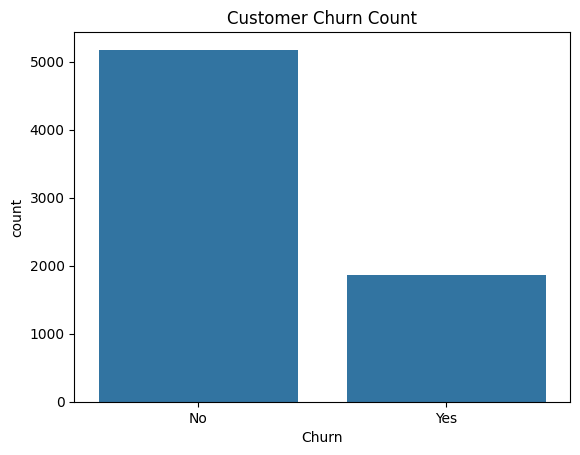

In [11]:
# Churn count
sns.countplot(x="Churn", data=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv"))
plt.title("Customer Churn Count")
plt.show()

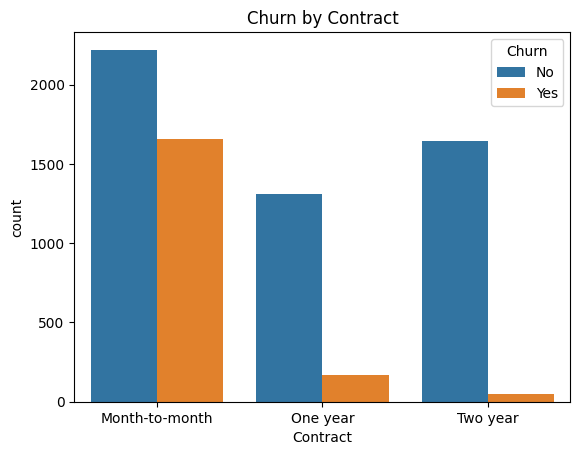

In [12]:
# Churn by Contract
original_df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
sns.countplot(x="Contract", hue="Churn", data=original_df)
plt.title("Churn by Contract")
plt.show()

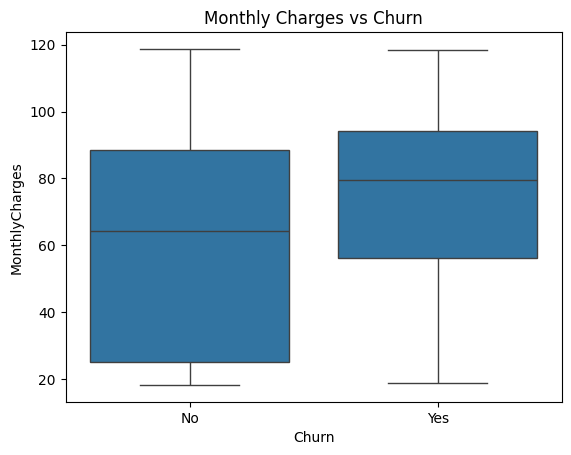

In [13]:
# Monthly Charges by Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=original_df)
plt.title("Monthly Charges vs Churn")
plt.show()

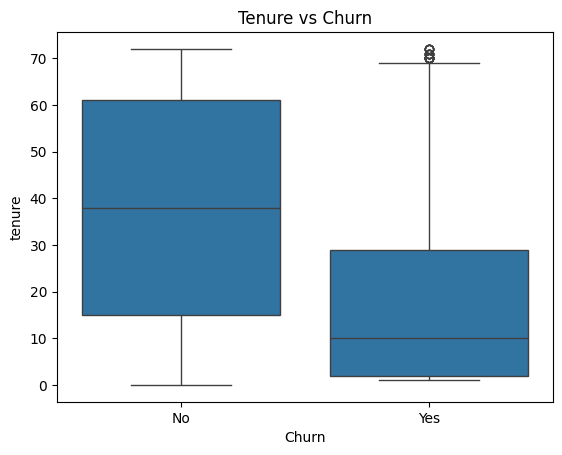

In [14]:
# Tenure by Churn
sns.boxplot(x="Churn", y="tenure", data=original_df)
plt.title("Tenure vs Churn")
plt.show()

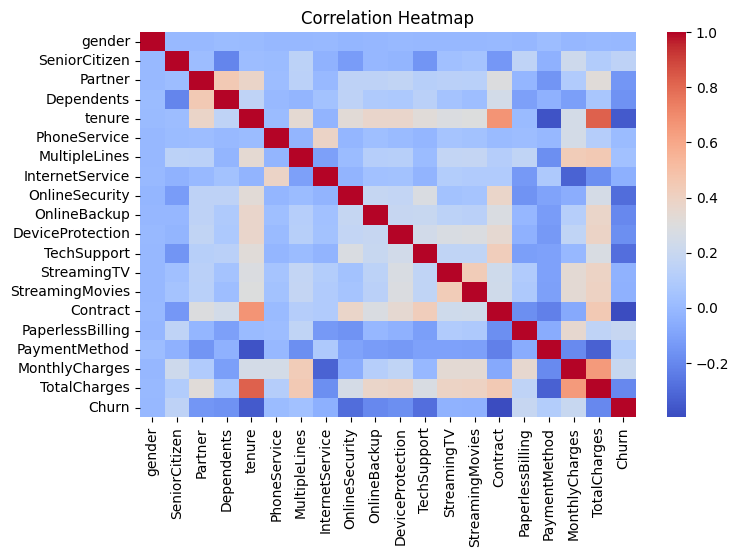

In [15]:
# Correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()